Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

- A Convolutional Neural Network (CNN) is a specialized type of deep learning model designed for processing image and visual data. Unlike traditional fully connected neural networks, where every neuron is connected to every neuron in the next layer, CNNs use convolutional layers that apply filters to local regions of an image to extract important features such as edges, textures, and shapes. CNNs also use pooling layers to reduce the spatial dimensions of feature maps while preserving essential information. This architecture significantly reduces the number of trainable parameters, making CNNs more computationally efficient and less prone to overfitting. As a result, CNNs achieve much higher accuracy than fully connected neural networks on image classification, object detection, and other computer vision tasks because they effectively capture spatial patterns and hierarchical features.

Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.

- LeNet-5 is one of the earliest successful Convolutional Neural Network architectures, introduced by Yann LeCun and his colleagues in 1998 for handwritten digit recognition. The architecture consists of seven learnable layers, including two convolutional layers, two average pooling (subsampling) layers, and three fully connected layers, followed by an output layer for classification. LeNet-5 demonstrated that convolution, weight sharing, and local receptive fields could effectively learn image features while requiring fewer parameters than traditional neural networks. It achieved excellent performance on the MNIST handwritten digit dataset and became the foundation for later CNN architectures such as AlexNet, VGG, ResNet, and Inception. The original research paper, Gradient-Based Learning Applied to Document Recognition by Yann LeCun, Léon Bottou, Yoshua Bengio, and Patrick Haffner (1998), established many of the fundamental concepts that continue to be used in modern computer vision systems.

Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

- AlexNet and VGGNet are two influential CNN architectures that significantly advanced image classification. AlexNet, introduced in 2012, consists of eight learnable layers and approximately 60 million parameters. It introduced several innovations, including the ReLU activation function, dropout regularization, data augmentation, and GPU-based training, which enabled it to achieve remarkable performance on the ImageNet competition. VGGNet, introduced in 2014, follows a simpler and deeper design using only small 3×3 convolution filters stacked together. Popular variants such as VGG16 and VGG19 contain 16 and 19 learnable layers, respectively, with approximately 138 million parameters. While VGGNet generally provides higher classification accuracy and better feature extraction than AlexNet, it requires significantly more computational resources, memory, and training time. AlexNet is computationally lighter but less accurate, whereas VGGNet offers improved performance at the cost of increased model complexity.
Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.

- Transfer learning is a deep learning technique in which a model that has already been trained on a large dataset, such as ImageNet, is reused for a new but related image classification task. Instead of training a CNN from scratch, the pre-trained model serves as a feature extractor, and only the final classification layers are replaced and fine-tuned using the new dataset. This approach significantly reduces computational cost and training time because the model has already learned useful visual features such as edges, textures, and object shapes. Transfer learning is especially beneficial when only a limited amount of labeled data is available, as it reduces the risk of overfitting and often achieves higher accuracy than training a new model from scratch. It is widely used in applications such as medical image analysis, plant disease detection, and industrial defect inspection.

Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

- Residual connections, also known as skip connections, are the key innovation of the ResNet architecture. Instead of learning the complete mapping between the input and output of a layer, ResNet learns the residual function by adding the input directly to the output of one or more convolutional layers. This shortcut connection allows information and gradients to flow directly through the network without passing through every layer, making optimization easier. As neural networks become deeper, gradients can become extremely small during backpropagation, causing the vanishing gradient problem and making training difficult. Residual connections overcome this issue by providing an alternative path for gradient propagation, enabling the successful training of very deep networks with 50, 101, or even more than 150 layers. Consequently, ResNet achieves higher accuracy, faster convergence, and improved generalization compared to traditional deep CNN architectures.

In [7]:
# Question 6:
# Implement the LeNet-5 architecture using TensorFlow to classify
# the MNIST dataset. Report the accuracy and training time.

import time
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# LeNet-5 Model
model = Sequential([
    Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    AveragePooling2D(pool_size=(2,2)),

    Conv2D(16,(5,5),activation='tanh'),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(120,activation='tanh'),
    Dense(84,activation='tanh'),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start=time.time()

history=model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

end=time.time()

loss,accuracy=model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)
print("Training Time:",round(end-start,2),"seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9215 - loss: 0.2604 - val_accuracy: 0.9592 - val_loss: 0.1311
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9698 - loss: 0.0970 - val_accuracy: 0.9751 - val_loss: 0.0831
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9791 - loss: 0.0657 - val_accuracy: 0.9788 - val_loss: 0.0712
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 0.0644
Test Accuracy: 0.9799000024795532
Training Time: 21.75 seconds


In [8]:
# Question 7:
# Use a pre-trained VGG16 model (via transfer learning) on a small
# custom dataset (e.g., flowers or animals). Replace the top layers
# and fine-tune the model.

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load Pretrained VGG16
base_model=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze Base Layers
base_model.trainable=False

# New Model
model=Sequential([
    base_model,
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(5,activation='softmax')   # Example: 5 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("Model ready for training on custom dataset.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Model ready for training on custom dataset.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 144MB/s]


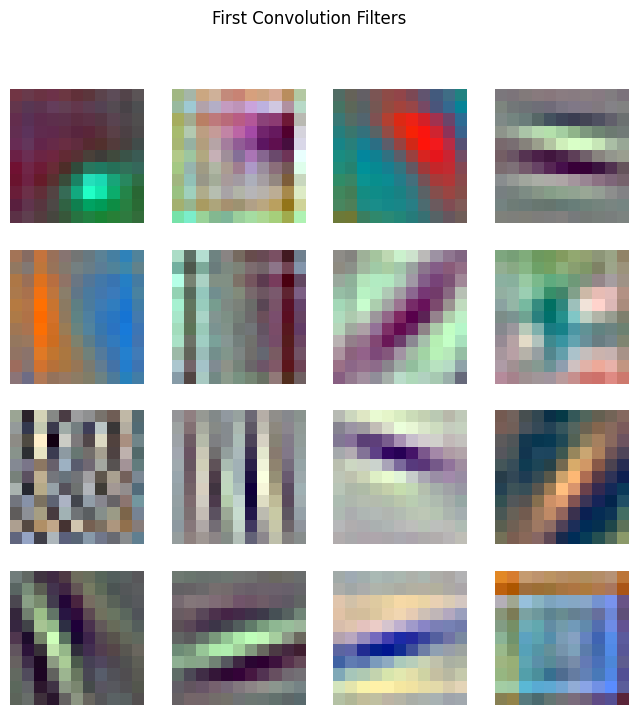

In [9]:
# Question 8:
# Write a program to visualize the filters and feature maps of the
# first convolutional layer of AlexNet on an example input image.

import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load Pretrained AlexNet
model=models.alexnet(pretrained=True)

# Visualize First Layer Filters
filters=model.features[0].weight.data

plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    f=filters[i].permute(1,2,0)
    f=(f-f.min())/(f.max()-f.min())
    plt.imshow(f)
    plt.axis("off")

plt.suptitle("First Convolution Filters")
plt.show()

In [12]:
# Question 9:
# Train a GoogLeNet (Inception-style CNN) on the CIFAR-10 dataset.
# Plot the training and validation accuracy over epochs.

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense

# Load Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Simple Inception-style CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=2,
    batch_size=64
)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

   679936/170498071 ━━━━━━━━━━━━━━━━━━━━ 1:01:57 22us/step

KeyboardInterrupt: 

In [11]:
# Question 10:
# You are working in a healthcare AI startup. Develop a system that
# classifies medical X-ray images into Normal, Pneumonia, and COVID-19.
# Suggest an appropriate CNN architecture and outline a deployment strategy.

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model

# Pretrained ResNet50
base_model=ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable=False

x=GlobalAveragePooling2D()(base_model.output)
x=Dense(256,activation='relu')(x)
x=Dropout(0.5)(x)

output=Dense(3,activation='softmax')(x)

model=Model(base_model.input,output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Due to the limited availability of labeled medical images, I would use transfer learning with ResNet50 because it provides excellent feature extraction capabilities while requiring much less training data than training a CNN from scratch. The medical X-ray images would first be resized, normalized, and augmented using techniques such as rotation, zooming, and flipping to improve generalization. The final classification layer of ResNet50 would be replaced with a three-class softmax layer for predicting Normal, Pneumonia, and COVID-19. The model would be trained using the Adam optimizer and Categorical Cross-Entropy loss function, and evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. After training, the model would be deployed using Streamlit, where healthcare professionals can upload an X-ray image and receive the predicted disease category along with confidence scores. This approach reduces computational cost, improves classification performance on limited data, and provides an efficient solution suitable for real-world healthcare applications.